# Feature engineering - VolatiChainXplorerAI

## Objectif

Construire les variables nécessaires à la prédiction de la volatilité future
du Bitcoin aux horizons de 7 et 30 jours.

## Données disponibles

- prix Bitcoin OHLC ;
- volume ;
- capitalisation ;
- taux MRO ;
- inflation ;
- chômage ;
- croissance de l’agrégat monétaire M3.

## Principes méthodologiques

- respecter l’ordre chronologique ;
- ne pas utiliser d’information future dans les features ;
- matérialiser les dates journalières manquantes ;
- conserver une méthode reproductible pour l’entraînement et l’inférence.

Dans le notebook, nous allons progressivement :

1. réindexer le calendrier quotidien ;
2. calculer les rendements logarithmiques ;
3. calculer les volatilités historiques sur 3, 7, 14 et 30 jours ;
4. calculer l’amplitude journalière ;
5. calculer les variations du volume et de la capitalisation ;
6. créer les cibles futures à 7 et 30 jours ;
7. vérifier les NaN, les distributions et l’absence de fuite temporelle.

## Audit du dataset

In [52]:
import sys

print(sys.executable)

d:\ProjectFolderDevAI_2025-2026\Certification BLOCS 2&3\Projet-VolatiChainXplorerAI\.venv\Scripts\python.exe


In [53]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [55]:
print(Path.cwd())

d:\ProjectFolderDevAI_2025-2026\Certification BLOCS 2&3\Projet-VolatiChainXplorerAI\notebooks


In [ ]:
# chemin du projet
project_root = Path.cwd().parent
path_dataset= (
    project_root
    / "data" 
    / "exports" 
    / "datasets"
    / "unprocessed" 
    / "btc_macro_dataset.csv"
)

print(f"Chemin du dataset :{path_dataset}")
print(f"Le dataset existe : {path_dataset.exists()}")

Chemin du dataset :d:\ProjectFolderDevAI_2025-2026\Certification BLOCS 2&3\Projet-VolatiChainXplorerAI\data\exports\datasets\btc_macro_dataset.csv
Le dataset existe : True


In [57]:
# Charger le dataset
df_raw = pd.read_csv(
    path_dataset,
    parse_dates=["date"]
)

df = df_raw.copy()

In [58]:
# Premier apperçu du dataset
display(df.head())
print(f"Dimension : {df.shape}")
print("Type :")
display(df.dtypes)

,date,open,high,low,close,volume,market_cap,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate
0,2010-07-14,0.045655,0.048348,0.038189,0.044277,205.314915,149358.200915,1.0,1.7,10.1,0.087906
1,2010-07-15,0.043730,0.052686,0.041843,0.044633,345.633197,151946.912726,1.0,1.7,10.1,0.087906
2,2010-07-16,0.044836,0.055827,0.044436,0.051399,384.382207,176284.305020,1.0,1.7,10.1,0.087906
3,2010-07-17,0.051405,0.059957,0.044286,0.050900,15.452590,175401.041475,1.0,1.7,10.1,0.087906
4,2010-07-18,0.050974,0.062366,0.049533,0.060789,57.947844,209538.725751,1.0,1.7,10.1,0.087906


Dimension : (5903, 11)
Type :


date                 datetime64[ns]
open                        float64
high                        float64
low                         float64
close                       float64
volume                      float64
market_cap                  float64
rate_mro                    float64
inflation_rate              float64
unemployment_rate           float64
monetary_m3_rate            float64
dtype: object

In [59]:
# Audit initial
audit = {
    "Nombre_lignes" : len(df),
    "Nombre_colonnes" : len(df.columns),
    "Premiere_date" : df["date"].min(),
    "Derniere_date" : df["date"].max(),
    "Date_dupliquees" : df["date"].duplicated().sum(),
    "Dataset_trie" : df["date"].is_monotonic_increasing,
    "Valeurs_manquantes" : int(df["date"].isna().sum())
}

pd.Series(audit)

Nombre_lignes                        5903
Nombre_colonnes                        11
Premiere_date         2010-07-14 00:00:00
Derniere_date         2026-09-12 00:00:00
Date_dupliquees                         0
Dataset_trie                         True
Valeurs_manquantes                      0
dtype: object

## 2. Construction du calendrier quotidien complet

Le Bitcoin est négocié tous les jours. Le dataset doit donc contenir une ligne
pour chaque journée comprise entre la première et la dernière observation.

Les dates absentes seront matérialisées par des lignes contenant des valeurs
manquantes. Aucune valeur financière ne sera inventée.

In [60]:
# Placer la date en index
df_daily = (
    df
    .sort_values("date")
    .set_index("date")
)

display(df_daily.head(10))

,open,high,low,close,volume,market_cap,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate
date,,,,,,,,,,
2010-07-14,0.045655,0.048348,0.038189,0.044277,205.314915,149358.200915,1.0,1.7,10.1,0.087906
2010-07-15,0.043730,0.052686,0.041843,0.044633,345.633197,151946.912726,1.0,1.7,10.1,0.087906
2010-07-16,0.044836,0.055827,0.044436,0.051399,384.382207,176284.305020,1.0,1.7,10.1,0.087906
2010-07-17,0.051405,0.059957,0.044286,0.050900,15.452590,175401.041475,1.0,1.7,10.1,0.087906
2010-07-18,0.050974,0.062366,0.049533,0.060789,57.947844,209538.725751,1.0,1.7,10.1,0.087906
2010-07-19,0.060778,0.064544,0.053298,0.057261,442.140585,197686.305250,1.0,1.7,10.1,0.087906
2010-07-20,0.057533,0.060156,0.049891,0.055843,203.597504,193480.201829,1.0,1.7,10.1,0.087906
2010-07-21,0.056245,0.059784,0.050237,0.058165,447.871547,202127.296414,1.0,1.7,10.1,0.087906
2010-07-22,0.057558,0.058218,0.039598,0.045683,1681.489031,159153.185842,1.0,1.7,10.1,0.087906


In [61]:
# Créer toutes les dates attendues# 
complete_date =pd.date_range(
    start=df_daily.index.min(),
    end=df_daily.index.max(),
    freq=("D")
)

In [62]:
# Identifier les dates absentes
missing_dates=complete_date.difference(df_daily.index)
print("Nombre de dates absentes :", len(missing_dates))
display(missing_dates)

Nombre de dates absentes : 2


DatetimeIndex(['2022-06-28', '2022-06-29'], dtype='datetime64[ns]', freq='D')

In [63]:
# Ajouter les lignes manquantes
df_daily = df_daily.reindex(complete_date)
df_daily.index.name = "date"

In [64]:
# Contrôler le résultat
print("Nombre de ligne avant la réindexation :", df.shape)
print("Nombre de ligne après la réindexation :", df_daily.shape)

display(
    df_daily["2022-06-25":"2022-07-02"]
)

display(df_daily.isna().sum())

Nombre de ligne avant la réindexation : (5903, 11)
Nombre de ligne après la réindexation : (5905, 10)


,open,high,low,close,volume,market_cap,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate
date,,,,,,,,,,
2022-06-25,20115.214406,20387.386543,19860.359351,20369.789007,1.740484e+10,3.885965e+11,0.0,8.6,6.8,5.966328
2022-06-26,20364.252865,20636.354199,19896.195040,19896.195040,1.707766e+10,3.800286e+11,0.0,8.6,6.8,5.966328
2022-06-27,19902.176070,20292.885437,19475.282605,19596.063434,1.984298e+10,3.744221e+11,0.0,8.6,6.8,5.966328
2022-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-30,19249.968917,19289.894218,17866.481291,18881.949425,2.514600e+10,3.614111e+11,0.0,8.6,6.8,5.966328
2022-07-01,18915.447972,19699.641234,18237.192775,18476.547863,2.936267e+10,3.509194e+11,0.0,8.9,6.7,5.770509
2022-07-02,18481.792419,18574.716472,18244.231120,18450.552217,1.735570e+10,3.521001e+11,0.0,8.9,6.7,5.770509


open                 2
high                 2
low                  2
close                2
volume               2
market_cap           2
rate_mro             2
inflation_rate       2
unemployment_rate    2
monetary_m3_rate     2
dtype: int64

## 3 - Calcul des rendements à chaque date
$$
r_t =
\ln\left(
\frac{
\text{Close}_t
}{
\text{Close}_{t-1}
}
\right)
$$

In [65]:
df_daily["log_return"] = np.log(
    df_daily["close"]/ df_daily["close"].shift(1)
)

df_daily["log_return_pct"] = df_daily["log_return"]*100

display(df_daily.head(10))

display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","log_return_pct"]
    ]
)

print(f"Nombre de rendements manquants : {df_daily['log_return'].isna().sum()}")

,open,high,low,close,volume,market_cap,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate,log_return,log_return_pct
date,,,,,,,,,,,,
2010-07-14,0.045655,0.048348,0.038189,0.044277,205.314915,149358.200915,1.0,1.7,10.1,0.087906,NaN,NaN
2010-07-15,0.043730,0.052686,0.041843,0.044633,345.633197,151946.912726,1.0,1.7,10.1,0.087906,0.008011,0.801083
2010-07-16,0.044836,0.055827,0.044436,0.051399,384.382207,176284.305020,1.0,1.7,10.1,0.087906,0.141146,14.114568
2010-07-17,0.051405,0.059957,0.044286,0.050900,15.452590,175401.041475,1.0,1.7,10.1,0.087906,-0.009756,-0.975635
2010-07-18,0.050974,0.062366,0.049533,0.060789,57.947844,209538.725751,1.0,1.7,10.1,0.087906,0.177546,17.754620
2010-07-19,0.060778,0.064544,0.053298,0.057261,442.140585,197686.305250,1.0,1.7,10.1,0.087906,-0.059794,-5.979416
2010-07-20,0.057533,0.060156,0.049891,0.055843,203.597504,193480.201829,1.0,1.7,10.1,0.087906,-0.025075,-2.507546
2010-07-21,0.056245,0.059784,0.050237,0.058165,447.871547,202127.296414,1.0,1.7,10.1,0.087906,0.040740,4.073971
2010-07-22,0.057558,0.058218,0.039598,0.045683,1681.489031,159153.185842,1.0,1.7,10.1,0.087906,-0.241559,-24.155949


,close,log_return,log_return_pct
date,,,
2022-06-25,20369.789007,0.012668,1.266844
2022-06-26,19896.195040,-0.023524,-2.352436
2022-06-27,19596.063434,-0.015200,-1.519981
2022-06-28,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,NaN
2022-07-01,18476.547863,-0.021704,-2.170416
2022-07-02,18450.552217,-0.001408,-0.140794


Nombre de rendements manquants : 4


## 4 - Calcul des volatilités à 3jrs, 7jrs, 14jrs et 30jrs

$$
\sigma_{t,n}
=
\sqrt{
\frac{1}{n-1}
\sum_{i=t-n+1}^{t}
\left(r_i-\bar{r}_{t,n}\right)^2
}
$$

- $\sigma_{t,n}$ : volatilité historique à la date $t$ sur une fenêtre de $n$ jours ;
- $r_i$ : rendement logarithmique du jour $i$ ;
- $\bar{r}_{t,n}$ : rendement logarithmique moyen sur les $n$ jours ;
- $n$ : taille de la fenêtre, ici 3, 7, 14 ou 30 jours.

In [66]:
# Volatilité lissée sur 3 jours
df_daily["volatility_3d"] = (
    df_daily["log_return"]
    .rolling(
        window=3,
        min_periods=3
    )
    .std()
)

display(df_daily[["volatility_3d"]].head(10))
display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","volatility_3d"]
    ])

print(f"Nombre de rendements manquants : {df_daily['volatility_3d'].isna().sum()}")

,volatility_3d
date,
2010-07-14,NaN
2010-07-15,NaN
2010-07-16,NaN
2010-07-17,0.082474
2010-07-18,0.099313
2010-07-19,0.125111
2010-07-20,0.128187
2010-07-21,0.051062
2010-07-22,0.147699


,close,log_return,volatility_3d
date,,,
2022-06-25,20369.789007,0.012668,0.028967
2022-06-26,19896.195040,-0.023524,0.018820
2022-06-27,19596.063434,-0.015200,0.018955
2022-06-28,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,NaN
2022-07-01,18476.547863,-0.021704,NaN
2022-07-02,18450.552217,-0.001408,NaN


Nombre de rendements manquants : 8


In [67]:
# Volatilité lissée sur 7 jours
df_daily["volatility_7d"] = (
    df_daily["log_return"]
    .rolling(
        window=7,
        min_periods=7
    )
    .std()
)

display(df_daily[["volatility_7d"]].head(10))
display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","volatility_7d"]
    ])

print(f"Nombre de rendements manquants : {df_daily['volatility_7d'].isna().sum()}")

,volatility_7d
date,
2010-07-14,NaN
2010-07-15,NaN
2010-07-16,NaN
2010-07-17,NaN
2010-07-18,NaN
2010-07-19,NaN
2010-07-20,NaN
2010-07-21,0.088351
2010-07-22,0.138851


,close,log_return,volatility_7d
date,,,
2022-06-25,20369.789007,0.012668,0.038990
2022-06-26,19896.195040,-0.023524,0.030267
2022-06-27,19596.063434,-0.015200,0.030987
2022-06-28,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,NaN
2022-07-01,18476.547863,-0.021704,NaN
2022-07-02,18450.552217,-0.001408,NaN


Nombre de rendements manquants : 16


In [68]:
# Volatilité lissée sur 14 jours
df_daily["volatility_14d"] = (
    df_daily["log_return"]
    .rolling(
        window=14,
        min_periods=14
    )
    .std()
)

display(df_daily[["volatility_14d"]].head(10))
display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","volatility_14d"]
    ])

print(f"Nombre de rendements manquants : {df_daily['volatility_14d'].isna().sum()}")

,volatility_14d
date,
2010-07-14,NaN
2010-07-15,NaN
2010-07-16,NaN
2010-07-17,NaN
2010-07-18,NaN
2010-07-19,NaN
2010-07-20,NaN
2010-07-21,NaN
2010-07-22,NaN


,close,log_return,volatility_14d
date,,,
2022-06-25,20369.789007,0.012668,0.064749
2022-06-26,19896.195040,-0.023524,0.063987
2022-06-27,19596.063434,-0.015200,0.047478
2022-06-28,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,NaN
2022-07-01,18476.547863,-0.021704,NaN
2022-07-02,18450.552217,-0.001408,NaN


Nombre de rendements manquants : 30


In [69]:
# Volatilité lissée sur 30 jours
df_daily["volatility_30d"] = (
    df_daily["log_return"]
    .rolling(
        window=30,
        min_periods=30
    )
    .std()
)

display(df_daily[["volatility_30d"]].head(35))
display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","volatility_30d"]
    ])

print(f"Nombre de rendements manquants : {df_daily['volatility_30d'].isna().sum()}")

,volatility_30d
date,
2010-07-14,NaN
2010-07-15,NaN
2010-07-16,NaN
2010-07-17,NaN
2010-07-18,NaN
2010-07-19,NaN
2010-07-20,NaN
2010-07-21,NaN
2010-07-22,NaN


,close,log_return,volatility_30d
date,,,
2022-06-25,20369.789007,0.012668,0.049881
2022-06-26,19896.195040,-0.023524,0.049894
2022-06-27,19596.063434,-0.015200,0.049704
2022-06-28,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,NaN
2022-07-01,18476.547863,-0.021704,NaN
2022-07-02,18450.552217,-0.001408,NaN


Nombre de rendements manquants : 62


## 5 - Calculer l’amplitude journalière
La formule retenue pour le calcul de l'amplitude est :
$$
\text{Amplitude}_t =
\frac{\text{High}_t - \text{Low}_t}{\text{Close}_t}
$$


In [70]:
df_daily["daily_range"] = (df_daily["high"] - df_daily["low"]) / df_daily["close"]

df_daily["daily_range_pct"] = (
    df_daily["daily_range"] * 100
)
# Verifier le resultat
display(df_daily[["daily_range","daily_range_pct"]].head(10))
display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","daily_range","daily_range_pct"]
    ])

print(f"Nombre d'amplitudes manquants : {df_daily['daily_range'].isna().sum()}")

,daily_range,daily_range_pct
date,,
2010-07-14,0.229451,22.945078
2010-07-15,0.242932,24.293243
2010-07-16,0.221633,22.163304
2010-07-17,0.307873,30.787295
2010-07-18,0.211099,21.109866
2010-07-19,0.196395,19.639471
2010-07-20,0.183814,18.381416
2010-07-21,0.164129,16.412931
2010-07-22,0.407592,40.759248


,close,log_return,daily_range,daily_range_pct
date,,,,
2022-06-25,20369.789007,0.012668,0.025873,2.587298
2022-06-26,19896.195040,-0.023524,0.037201,3.720104
2022-06-27,19596.063434,-0.015200,0.041723,4.172281
2022-06-28,NaN,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,0.075385,7.538485
2022-07-01,18476.547863,-0.021704,0.079152,7.915161
2022-07-02,18450.552217,-0.001408,0.017912,1.791195


Nombre d'amplitudes manquants : 2


## 6 - Calculer les variations du volume et de la capitalisation 

###  Calcul de la variation relative du volume
$$
    \text{VariationVolume}_t
    ​=
    \frac{\text{Volume}_t}{\text{​Volume}_{t−1}​​}
    -1
$$


In [71]:
df_daily["volume_change"] = (df_daily["volume"] - df_daily["volume"].shift(1)) / df_daily["volume"].shift(1)

df_daily["volume_change_pct"] = df_daily["volume_change"] *100 

# Vérifier le resultat
display(
    df_daily[["volume", "volume_change", "volume_change_pct"]].head(10)
)

display(
    df_daily.loc[
        "2022-06-25":"2022-07-02",
        ["close","log_return","daily_range","daily_range_pct", "volume", "volume_change", "volume_change_pct"]
    ])

print(
    "Nombre de variations du volume manquantes :",
    df_daily["volume_change"].isna().sum()
)

,volume,volume_change,volume_change_pct
date,,,
2010-07-14,205.314915,NaN,NaN
2010-07-15,345.633197,0.683430,68.342956
2010-07-16,384.382207,0.112110,11.211021
2010-07-17,15.452590,-0.959799,-95.979889
2010-07-18,57.947844,2.750041,275.004090
2010-07-19,442.140585,6.629975,662.997471
2010-07-20,203.597504,-0.539519,-53.951863
2010-07-21,447.871547,1.199789,119.978899
2010-07-22,1681.489031,2.754400,275.440021


,close,log_return,daily_range,daily_range_pct,volume,volume_change,volume_change_pct
date,,,,,,,
2022-06-25,20369.789007,0.012668,0.025873,2.587298,1.740484e+10,-0.266409,-26.640852
2022-06-26,19896.195040,-0.023524,0.037201,3.720104,1.707766e+10,-0.018798,-1.879807
2022-06-27,19596.063434,-0.015200,0.041723,4.172281,1.984298e+10,0.161926,16.192623
2022-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-30,18881.949425,NaN,0.075385,7.538485,2.514600e+10,NaN,NaN
2022-07-01,18476.547863,-0.021704,0.079152,7.915161,2.936267e+10,0.167688,16.768783
2022-07-02,18450.552217,-0.001408,0.017912,1.791195,1.735570e+10,-0.408920,-40.891980


Nombre de variations du volume manquantes : 250


In [72]:
volume_audit = pd.DataFrame({
    "volume": df_daily["volume"],
    "volume_precedent": df_daily["volume"].shift(1),
    "volume_change": df_daily["volume_change"]
})

print("Volumes manquants :", df_daily["volume"].isna().sum())
print("Volumes égaux à zéro :", df_daily["volume"].eq(0).sum())
print(
    "Deux volumes nuls consécutifs :",
    (
        df_daily["volume"].eq(0)
        & df_daily["volume"].shift(1).eq(0)
    ).sum()
)

display(
    volume_audit.loc[
        volume_audit["volume_change"].isna()
    ].head(20)
)

Volumes manquants : 2
Volumes égaux à zéro : 248
Deux volumes nuls consécutifs : 246


,volume,volume_precedent,volume_change
date,,,
2010-07-14,205.314915,NaN,NaN
2011-06-21,0.000000,0.0,NaN
2011-06-22,0.000000,0.0,NaN
2011-06-23,0.000000,0.0,NaN
2011-06-24,0.000000,0.0,NaN
2011-06-25,0.000000,0.0,NaN
2013-04-30,0.000000,0.0,NaN
2013-05-01,0.000000,0.0,NaN
2013-05-02,0.000000,0.0,NaN


In [73]:
print(
    "Valeurs infinies :",
    np.isinf(df_daily["volume_change"]).sum()
)

display(
    df_daily.loc[
        np.isinf(df_daily["volume_change"]),
        ["volume", "volume_change"]
    ].head(20)
)

Valeurs infinies : 2


,volume,volume_change
date,,
2011-06-26,1.059152e+04,inf
2013-12-27,3.422384e+07,inf


In [74]:
# Créer une série nettoyée sans modifier le volume original
volume_clean = df_daily["volume"].replace(0, np.nan)

# Calculer la variation relative du volume
df_daily["volume_change"] = (
    volume_clean / volume_clean.shift(1) - 1
)

# Conversion en pourcentage pour l'affichage
df_daily["volume_change_pct"] = (
    df_daily["volume_change"] * 100
)

print(
    "Variations manquantes :",
    df_daily["volume_change"].isna().sum()
)

print(
    "Valeurs infinies :",
    np.isinf(df_daily["volume_change"]).sum()
)

Variations manquantes : 254
Valeurs infinies : 0


### Calcul de la variation relative de la capitalisation
$$
    \text{VariationCapitalisation}_t
    ​=
    \frac{\text{capitalisation}_t}{\text{capitalisation}_{t−1}​​}
    -1
$$

In [75]:
df_daily["market_cap_change"] = (df_daily["market_cap"] - df_daily["market_cap"].shift(1)) / df_daily["market_cap"].shift(1)

df_daily["market_cap_change_pct"] = df_daily["market_cap_change"] *100 


print(
    "Variations de capitalisation manquantes :",
    df_daily["market_cap_change"].isna().sum()
)

print(
    "Valeurs infinies :",
    np.isinf(df_daily["market_cap_change"]).sum()
)

Variations de capitalisation manquantes : 4
Valeurs infinies : 0


## 7 - Créer les cibles futures : les volatilités à 7 et 30 jours

### Construction de la volatilité future

La volatilité future constitue la **variable cible** que le modèle doit prédire. Pour chaque date \(t\), elle correspond à l’écart-type des rendements logarithmiques observés durant les jours suivants.

Pour un horizon de 7 jours :

$$
\text{VolatilitéFuture}_{7,t}
=
\sigma(r_{t+1}, r_{t+2}, \ldots, r_{t+7})
$$

La méthode `shift(-1)` permet d’exclure le rendement du jour \(t\) et de commencer le calcul à \(t+1\). Une fenêtre glissante orientée vers l’avenir sélectionne ensuite les 7 rendements futurs.

Les features utilisent uniquement les informations connues jusqu’à la date \(t\), tandis que la cible utilise les observations postérieures à cette date. Cette séparation est indispensable pour éviter toute fuite de données.

Les dernières lignes du dataset ne possèdent pas de cible complète, car les observations futures nécessaires ne sont pas encore disponibles.


### Créer la volatilité glissante sur 7 jours

In [76]:
# Créer la fenêtre future sur 7 jours
from pandas.api.indexers import FixedForwardWindowIndexer

forward_window_7d = FixedForwardWindowIndexer(
    window_size=7
)

In [77]:
# Calculer la volatilité sur 7 jours
df_daily["target_volatility_7d"] = (
    df_daily["log_return"]
    .shift(-1)
    .rolling(
        window=forward_window_7d,
        min_periods=7
    )
    .std()
)

In [78]:
# Contrôler visuellement le resultat
display(
    df_daily[
        ["log_return","target_volatility_7d"]             
    ].tail(12)
)

# calculer le nombre de valeurs manquantes dans la volatilité sur 7 jours
print(
    "Nombre de valeurs manquantes dans les volatilités sur 7 jours :",
    df_daily["target_volatility_7d"].isna().sum()
)
# Visualiser les valeurs manquantes
display(
    df_daily.loc[
        df_daily["target_volatility_7d"].isna(),
        ["log_return", "target_volatility_7d"]
    ]
)

,log_return,target_volatility_7d
date,,
2026-09-01,-0.012533,0.021909
2026-09-02,-0.000682,0.021960
2026-09-03,0.046374,0.010496
2026-09-04,-0.018759,0.011005
2026-09-05,0.001991,0.010949
2026-09-06,0.006499,NaN
2026-09-07,-0.016399,NaN
2026-09-08,-0.008769,NaN
2026-09-09,-0.002887,NaN


Nombre de valeurs manquantes dans les volatilités sur 7 jours : 16


,log_return,target_volatility_7d
date,,
2022-06-21,0.003902,NaN
2022-06-22,-0.038291,NaN
2022-06-23,0.057642,NaN
2022-06-24,0.003527,NaN
2022-06-25,0.012668,NaN
2022-06-26,-0.023524,NaN
2022-06-27,-0.015200,NaN
2022-06-28,NaN,NaN
2022-06-29,NaN,NaN


### Créer la volatilité glissante sur 30 jours

In [79]:
# Créer la fenêtre future sur 30 jours
forward_window_30d = FixedForwardWindowIndexer(
    window_size=30
)

In [80]:
# Calculer la volatilité sur 30 jours
df_daily["target_volatility_30d"]=(
    df_daily["log_return"]
    .shift(-1)
    .rolling(
        window=forward_window_30d,
        min_periods=30
    )
    .std()
)

In [81]:
# Contrôler visuellement le resultat
display(
    df_daily[
        ["log_return","target_volatility_30d"]             
    ].tail(12)
)

# calculer le nombre de valeurs manquantes dans la volatilité sur 30 jours
print(
    "Nombre de valeurs manquantes dans les volatilités sur 30 jours :",
    df_daily["target_volatility_30d"].isna().sum()
)
# Visualiser les valeurs manquantes
display(
    df_daily.loc[
        df_daily["target_volatility_30d"].isna(),
        ["log_return", "target_volatility_30d"]
    ]
)

,log_return,target_volatility_30d
date,,
2026-09-01,-0.012533,NaN
2026-09-02,-0.000682,NaN
2026-09-03,0.046374,NaN
2026-09-04,-0.018759,NaN
2026-09-05,0.001991,NaN
2026-09-06,0.006499,NaN
2026-09-07,-0.016399,NaN
2026-09-08,-0.008769,NaN
2026-09-09,-0.002887,NaN


Nombre de valeurs manquantes dans les volatilités sur 30 jours : 62


,log_return,target_volatility_30d
date,,
2022-05-29,0.014754,NaN
2022-05-30,0.070388,NaN
2022-05-31,0.005568,NaN
2022-06-01,-0.056969,NaN
2022-06-02,0.013170,NaN
...,...,...
2026-09-08,-0.008769,NaN
2026-09-09,-0.002887,NaN
2026-09-10,-0.019773,NaN


### Vérifier objectivement l’égalité entre le calcul manuel et la cible générée

In [82]:
# Vérification manuelle de la volatilité cible sur 7 jours
date_test = "2026-08-13"

volatility_manual = (
    df_daily.loc[
        "2026-08-14":"2026-08-20",
        "log_return"
    ]
    .std()
)

volatility_target = df_daily.loc[
    date_test,
    "target_volatility_7d"
]

print("Calcul manuel :", volatility_manual)
print("Cible calculée :", volatility_target)
print(
    "Résultats identiques :",
    np.isclose(volatility_manual, volatility_target)
)

Calcul manuel : 0.028009022529038603
Cible calculée : 0.02800902252903874
Résultats identiques : True


In [83]:
# Vérification manuelle de la volatilité cible sur 30 jours
date_test = "2026-08-13"

volatility_manual = (
    df_daily.loc[
        "2026-08-14":"2026-09-12",
        "log_return"
    ]
    .std()
)

volatility_target = df_daily.loc[
    date_test,
    "target_volatility_30d"
]

print("Calcul manuel :", volatility_manual)
print("Cible calculée :", volatility_target)
print(
    "Résultats identiques :",
    np.isclose(volatility_manual, volatility_target)
)

Calcul manuel : 0.023541394025768186
Cible calculée : 0.02354139402576806
Résultats identiques : True


## 8 - Vérifier les NaN, les distributions et l’absence de fuite temporelle.

In [84]:
# 1. Vérifier toutes les valeurs manquantes dans le DataFrame
display(
    df_daily
    .isna()
    .sum()
    .sort_values(ascending=False)
)

volume_change_pct        254
volume_change            254
target_volatility_30d     62
volatility_30d            62
volatility_14d            30
target_volatility_7d      16
volatility_7d             16
volatility_3d              8
market_cap_change_pct      4
market_cap_change          4
log_return_pct             4
log_return                 4
close                      2
low                        2
high                       2
open                       2
inflation_rate             2
rate_mro                   2
market_cap                 2
volume                     2
monetary_m3_rate           2
unemployment_rate          2
daily_range                2
daily_range_pct            2
dtype: int64

In [85]:
# 2. Vérifier les valeurs infinies
numerics_columns = df_daily.select_dtypes(include= "number").columns

display(
    pd.Series(
    {
       column: np.isinf(df_daily[column]).sum()
       for column in numerics_columns
    },
    name="nombres_infinis"
    ).sort_values(ascending=False)
)

open                     0
high                     0
low                      0
close                    0
volume                   0
market_cap               0
rate_mro                 0
inflation_rate           0
unemployment_rate        0
monetary_m3_rate         0
log_return               0
log_return_pct           0
volatility_3d            0
volatility_7d            0
volatility_14d           0
volatility_30d           0
daily_range              0
daily_range_pct          0
volume_change            0
volume_change_pct        0
market_cap_change        0
market_cap_change_pct    0
target_volatility_7d     0
target_volatility_30d    0
Name: nombres_infinis, dtype: int64

In [86]:
# 3. Vérifier les distributions
display(
    df_daily[numerics_columns]
    .describe( percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
open,5903.0,1.948529e+04,2.740174e+04,0.043709,0.050982,1.723826e+00,2.538425e+02,5.677914e+03,3.015807e+04,8.541153e+04,9.911389e+04,1.065378e+05
high,5903.0,1.986184e+04,2.787136e+04,0.045580,0.057938,1.986052e+00,2.586789e+02,5.766422e+03,3.131959e+04,8.696674e+04,1.002838e+05,1.077626e+05
low,5903.0,1.908994e+04,2.690580e+04,0.037530,0.045409,1.508216e+00,2.493216e+02,5.571884e+03,2.878166e+04,8.308941e+04,9.774685e+04,1.051678e+05
close,5903.0,1.949583e+04,2.740665e+04,0.043648,0.051407,1.739574e+00,2.538499e+02,5.677876e+03,3.015852e+04,8.541016e+04,9.912238e+04,1.065337e+05
volume,5903.0,1.478508e+10,1.937045e+10,0.000000,0.000000,1.758525e+03,1.364349e+07,4.933571e+09,2.571729e+10,5.176496e+10,7.784297e+10,2.886746e+11
market_cap,5903.0,3.785808e+11,5.436712e+11,149358.200915,190083.556779,1.323342e+07,3.513799e+09,9.795562e+10,5.641850e+11,1.692065e+12,1.973403e+12,2.122872e+12
rate_mro,5903.0,9.818397e-01,1.368736e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,1.500000e-01,1.500000e+00,4.250000e+00,4.500000e+00,4.500000e+00
inflation_rate,5903.0,2.214230e+00,2.173119e+00,-0.600000,-0.300000,-1.000000e-01,8.000000e-01,1.900000e+00,2.600000e+00,8.100000e+00,1.010000e+01,1.060000e+01
unemployment_rate,5903.0,8.808894e+00,1.993442e+00,6.300000,6.300000,6.300000e+00,6.800000e+00,8.400000e+00,1.050000e+01,1.200000e+01,1.220000e+01,1.220000e+01
monetary_m3_rate,5903.0,3.991539e+00,2.563969e+00,-1.274453,-1.190917,7.154249e-01,2.266955e+00,3.741066e+00,5.040617e+00,9.373408e+00,1.227274e+01,1.249179e+01


## 9 - Analyse exploratoire des données

### 1. Examiner les valeurs extrêmes

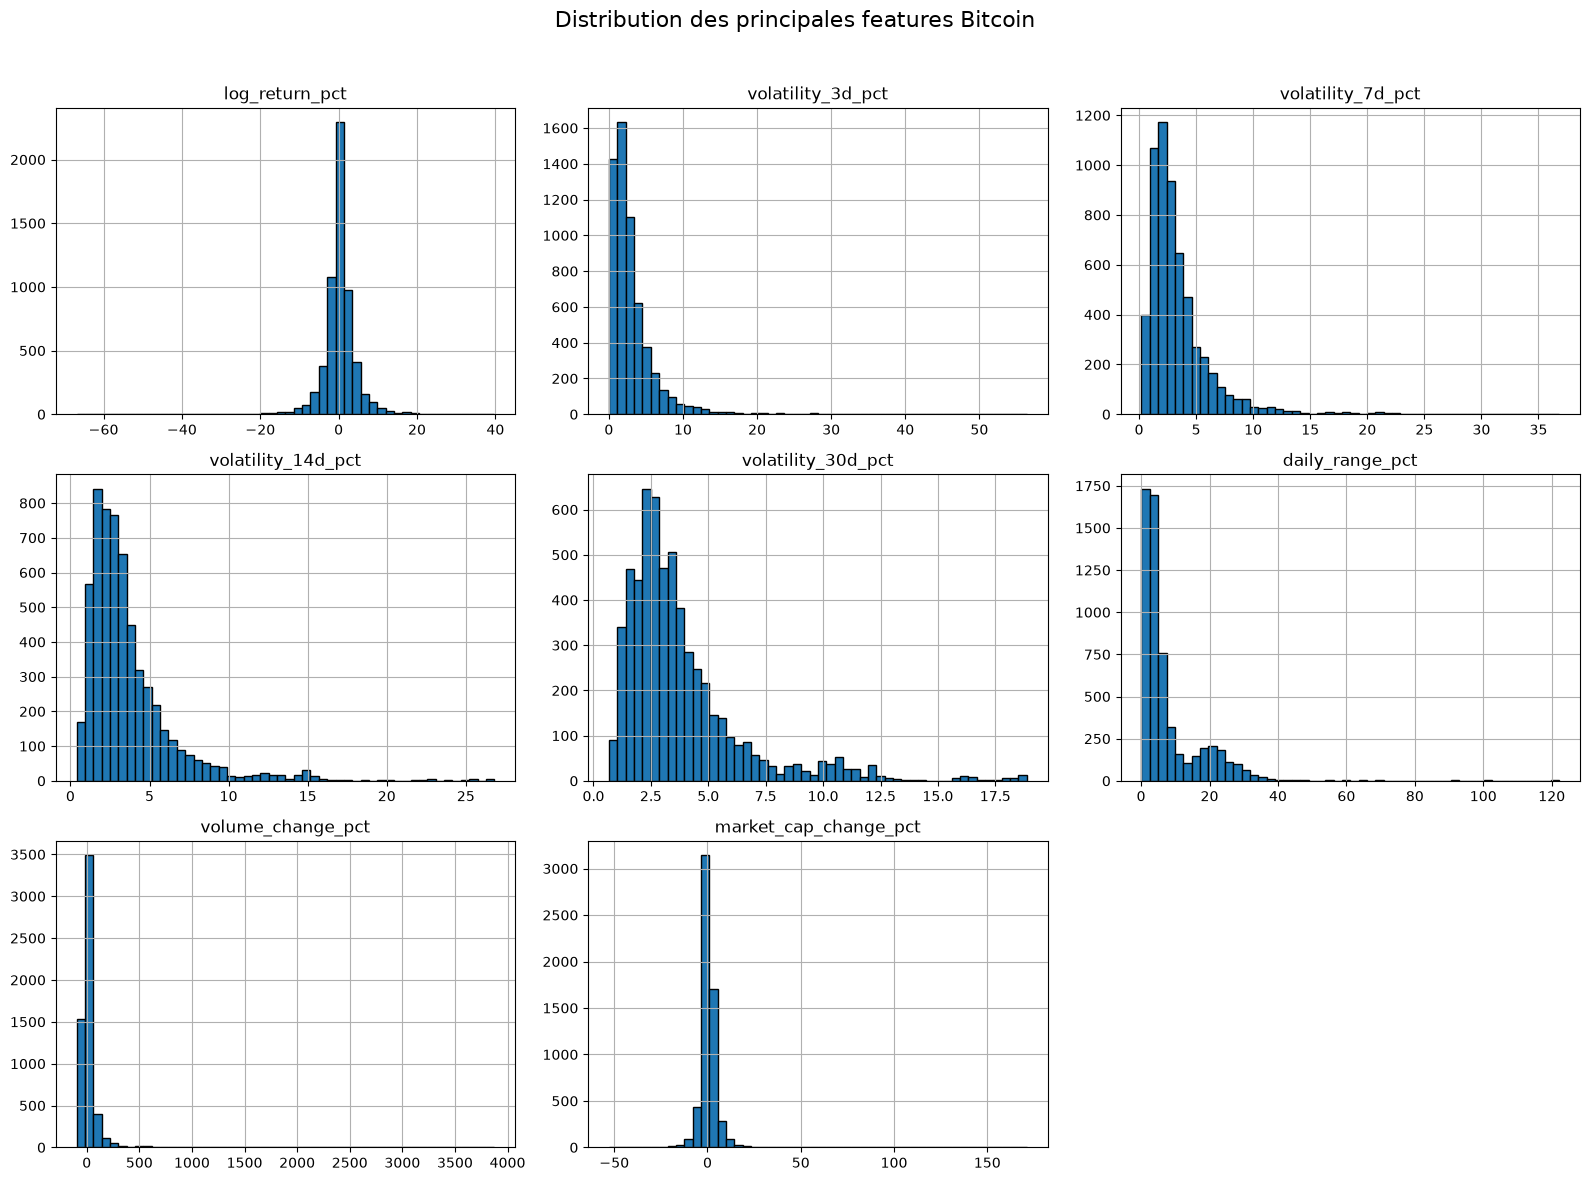

In [87]:
# Features principales à analyser
features_to_plot = [
    "log_return",
    "volatility_3d",
    "volatility_7d",
    "volatility_14d",
    "volatility_30d",
    "daily_range",
    "volume_change",
    "market_cap_change"
]

# Copie temporaire en pourcentage pour faciliter la lecture
features_pct = (
    df_daily[features_to_plot]
    .copy()
    * 100
)

# Renommer uniquement les colonnes de cette copie
features_pct.columns = [
    f"{column}_pct"
    for column in features_pct.columns
]

# Tracer les histogrammes
features_pct.hist(
    bins=50,
    figsize=(16, 12),
    layout=(3, 3),
    edgecolor="black"
)

plt.suptitle(
    "Distribution des principales features Bitcoin",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

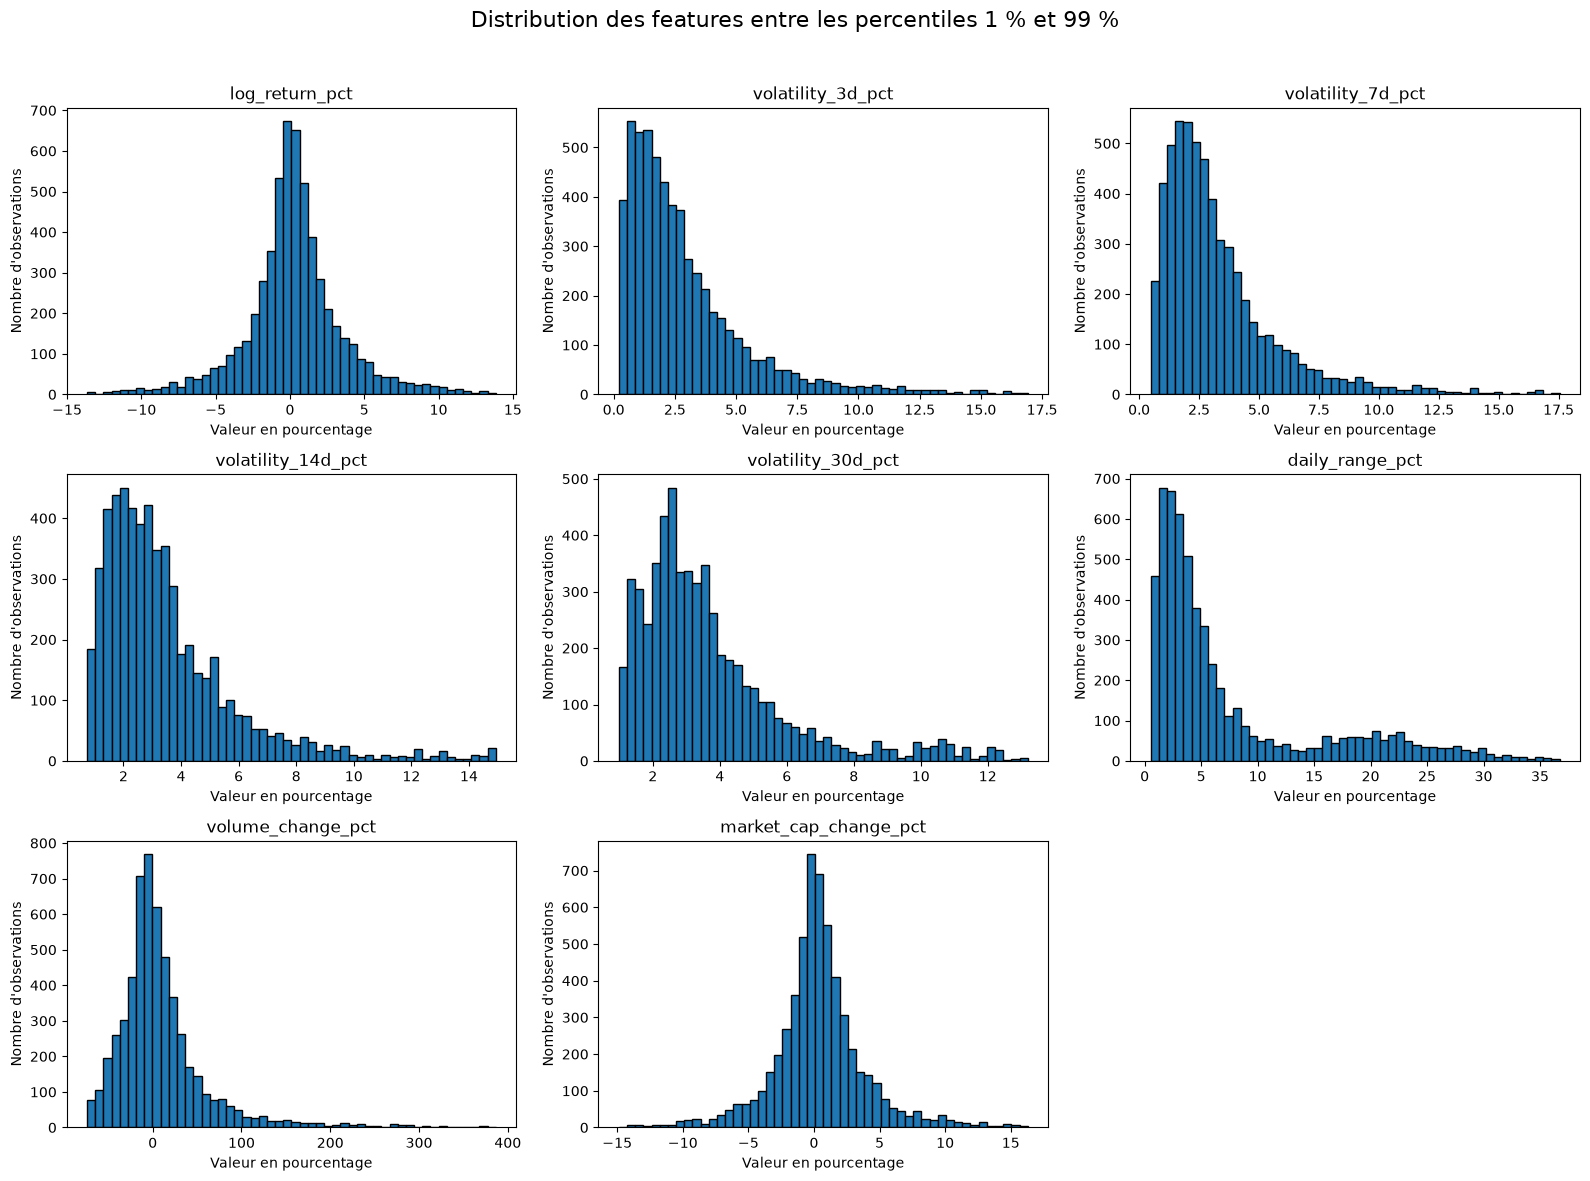

In [88]:
# Agrandir la zone habituelle des graphiques
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 12)
)

axes = axes.flatten()

for index, column in enumerate(features_pct.columns):
    
    values = features_pct[column].dropna()

    lower_limit = values.quantile(0.01)
    upper_limit = values.quantile(0.99)

    values_zoomed = values[
        values.between(
            lower_limit,
            upper_limit
        )
    ]

    axes[index].hist(
        values_zoomed,
        bins=50,
        edgecolor="black"
    )

    axes[index].set_title(column)
    axes[index].set_xlabel("Valeur en pourcentage")
    axes[index].set_ylabel("Nombre d'observations")

# Masquer la case inutilisée
for index in range(
    len(features_pct.columns),
    len(axes)
):
    axes[index].set_visible(False)

plt.suptitle(
    "Distribution des features entre les percentiles 1 % et 99 %",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

C:\Users\PATRICIA\AppData\Local\Temp\ipykernel_25384\1018733136.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[index].boxplot(
C:\Users\PATRICIA\AppData\Local\Temp\ipykernel_25384\1018733136.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[index].boxplot(
C:\Users\PATRICIA\AppData\Local\Temp\ipykernel_25384\1018733136.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[index].boxplot(
C:\Users\PATRICIA\AppData\Local\Temp\ipykernel_25384\1018733136.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[index].boxpl

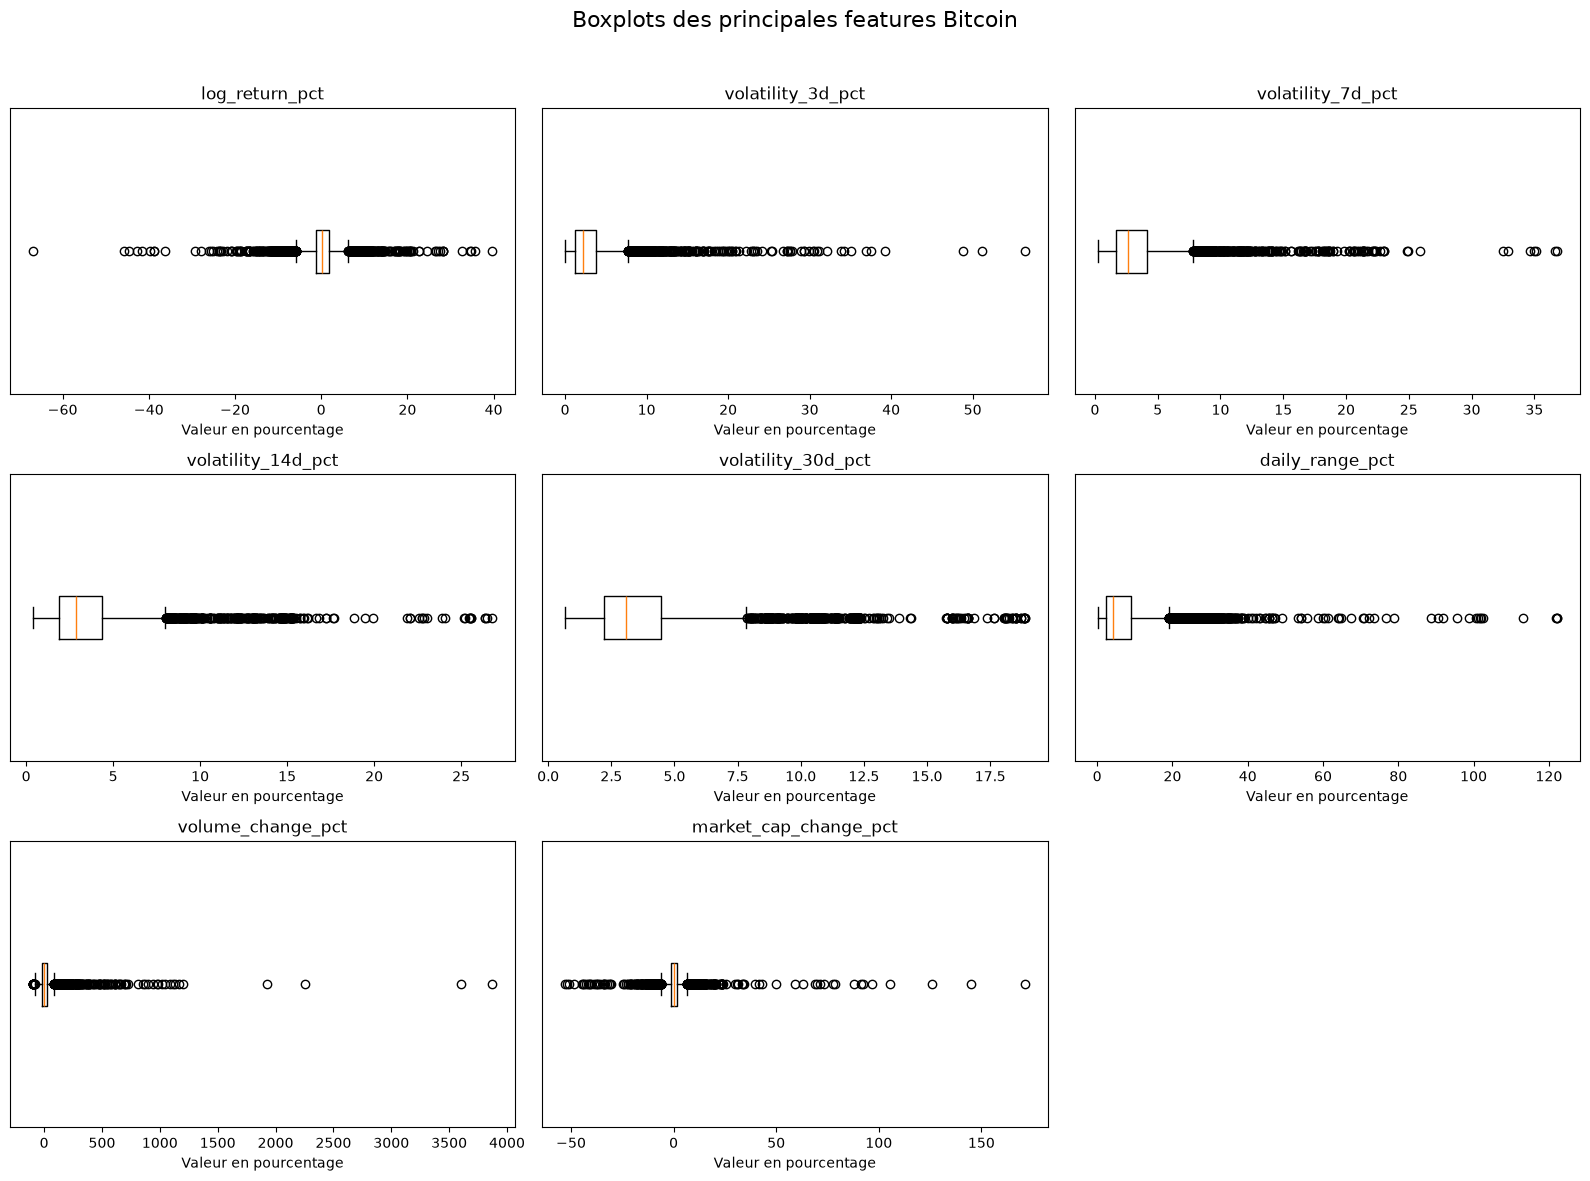

In [89]:
# Boxplots des principales features Bitcoin
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 12)
)

axes = axes.flatten()

for index, column in enumerate(features_pct.columns):

    values = features_pct[column].dropna()

    axes[index].boxplot(
        values,
        vert=False,
        showfliers=True
    )

    axes[index].set_title(column)
    axes[index].set_xlabel("Valeur en pourcentage")
    axes[index].set_yticks([])

# Masquer la case inutilisée
for index in range(
    len(features_pct.columns),
    len(axes)
):
    axes[index].set_visible(False)

plt.suptitle(
    "Boxplots des principales features Bitcoin",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

In [90]:
# Retrouver les dates extrêmes
features_extremes = [
    "log_return_pct",
    "daily_range_pct",
    "volume_change_pct",
    "market_cap_change_pct"
]

for column in features_extremes:
    print(f"\n===== {column} =====")

    print("\n5 valeurs les plus faibles :")
    display(
        df_daily[[column]]
        .dropna()
        .nsmallest(5, column)
    )

    print("\n5 valeurs les plus élevées :")
    display(
        df_daily[[column]]
        .dropna()
        .nlargest(5, column)
    )


===== log_return_pct =====

5 valeurs les plus faibles :


,log_return_pct
date,
2010-11-09,-66.869007
2020-03-12,-45.793149
2010-08-17,-44.535216
2010-09-17,-42.765962
2013-04-11,-41.522860



5 valeurs les plus élevées :


,log_return_pct
date,
2013-04-18,39.708286
2013-11-18,35.604262
2011-06-04,34.726931
2010-11-10,34.403344
2011-05-10,32.640840



===== daily_range_pct =====

5 valeurs les plus faibles :


...

,volume_change_pct
date,
2011-11-14,3873.444032
2010-11-22,3602.179512
2010-12-26,2257.846965
2010-11-26,1927.833583
2011-12-19,1196.776694



===== market_cap_change_pct =====

5 valeurs les plus faibles :


,market_cap_change_pct
date,
2011-04-15,-52.774166
2011-03-21,-51.981151
2011-07-24,-50.969494
2010-11-09,-48.466078
2013-02-18,-44.543608



5 valeurs les plus élevées :


,market_cap_change_pct
date,
2011-06-03,171.101935
2011-09-11,144.901827
2011-04-14,126.050263
2011-07-23,105.369321
2011-03-20,96.921828


In [91]:
# Vérifier les données sources autour de chaque date
dates_extremes = [
    "2010-11-22",  # volume
    "2011-11-14",  # volume
    "2011-03-04",  # amplitude
    "2013-01-11",  # amplitude
    "2010-11-09",  # rendement/capitalisation
    "2011-06-03"   # capitalisation
]

for date in dates_extremes:
    position = df_daily.index.get_loc(date)

    print(f"\n===== Contrôle autour du {date} =====")

    display(
        df_daily.iloc[
            max(0, position - 1): position + 2
        ][[
            "open",
            "high",
            "low",
            "close",
            "volume",
            "market_cap",
            "log_return_pct",
            "daily_range_pct",
            "volume_change_pct",
            "market_cap_change_pct"
        ]]
    )


===== Contrôle autour du 2010-11-22 =====


,open,high,low,close,volume,market_cap,log_return_pct,daily_range_pct,volume_change_pct,market_cap_change_pct
date,,,,,,,,,,
2010-11-21,0.205154,0.215816,0.181801,0.207466,559.379168,966485.790131,1.018082,16.395642,-94.759573,1.155968
2010-11-22,0.206616,0.215349,0.172123,0.211355,20709.220966,982771.267887,1.856934,20.451871,3602.179512,1.685020
2010-11-23,0.214617,0.214953,0.170026,0.209246,3626.759757,977960.371533,-1.002431,21.470682,-82.487223,-0.489524



===== Contrôle autour du 2011-11-14 =====


,open,high,low,close,volume,market_cap,log_return_pct,daily_range_pct,volume_change_pct,market_cap_change_pct
date,,,,,,,,,,
2011-11-13,2.206388,2.312202,1.878383,2.253957,7053.019467,1.726052e+07,1.868241,19.246991,-52.542574,1.981685
2011-11-14,2.259956,2.341252,1.541676,1.847944,280247.781084,1.416444e+07,-19.861375,43.268430,3873.444032,-17.937358
2011-11-15,1.847759,2.210404,1.735488,2.047286,56086.041899,1.557670e+07,10.244143,23.197356,-79.986981,9.970461



===== Contrôle autour du 2011-03-04 =====


...

,open,high,low,close,volume,market_cap,log_return_pct,daily_range_pct,volume_change_pct,market_cap_change_pct
date,,,,,,,,,,
2013-01-10,10.410834,11.018163,8.850136,10.618147,39183.857002,1.130951e+08,0.694490,20.418128,78.108481,0.731663
2013-01-11,10.618532,22.523299,9.559731,10.618919,30520.932243,1.139656e+08,0.007266,122.079921,-22.108402,0.769708
2013-01-12,10.620247,11.840794,9.624964,10.737769,20091.264923,1.144093e+08,1.113009,20.635848,-34.172178,0.389346



===== Contrôle autour du 2010-11-09 =====


,open,high,low,close,volume,market_cap,log_return_pct,daily_range_pct,volume_change_pct,market_cap_change_pct
date,,,,,,,,,,
2010-11-08,0.242251,0.328338,0.242251,0.315938,84154.164354,1.416789e+06,26.722283,27.247957,53.334879,29.743870
2010-11-09,0.314940,0.314940,0.149851,0.161880,34383.879476,7.301271e+05,-66.869007,101.982367,-59.141797,-48.466078
2010-11-10,0.162201,0.242802,0.162201,0.228352,21880.431325,1.033657e+06,34.403344,35.296690,-36.364274,41.572223



===== Contrôle autour du 2011-06-03 =====


,open,high,low,close,volume,market_cap,log_return_pct,daily_range_pct,volume_change_pct,market_cap_change_pct
date,,,,,,,,,,
2011-06-02,6.628864,7.376312,6.003744,6.976496,28464.387833,4.498118e+07,5.106396,19.674184,-6.002695,6.007914
2011-06-03,14.742113,14.742113,6.665367,8.912429,106514.737051,1.219449e+08,24.490004,90.623406,274.203505,171.101935
2011-06-04,8.961493,12.786767,8.961493,12.612849,30384.463419,8.094229e+07,34.726931,30.328384,-71.473935,-33.623861


In [92]:
# vérifier automatiquement la cohérence OHLC pour détecter les anomalies
ohlc_anomalies = df_daily.loc[
    (df_daily["high"] < df_daily[["open", "close"]].max(axis=1))
    | (df_daily["low"] > df_daily[["open", "close"]].min(axis=1))
    | (df_daily["high"] < df_daily["low"])
]

print("Nombre d'anomalies OHLC :", len(ohlc_anomalies))
display(ohlc_anomalies.head(20))

Nombre d'anomalies OHLC : 0


,open,high,low,close,volume,market_cap,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate,...,volatility_14d,volatility_30d,daily_range,daily_range_pct,volume_change,volume_change_pct,market_cap_change,market_cap_change_pct,target_volatility_7d,target_volatility_30d
date,,,,,,,,,,,,,,,,,,,,,


In [93]:
df_daily["estimated_supply"] = (
    df_daily["market_cap"] / df_daily["close"]
)

display(
    df_daily.loc[
        "2011-06-02":"2011-06-04",
        ["close", "market_cap", "estimated_supply"]
    ]
)

,close,market_cap,estimated_supply
date,,,
2011-06-02,6.976496,4.498118e+07,6.447533e+06
2011-06-03,8.912429,1.219449e+08,1.368256e+07
2011-06-04,12.612849,8.094229e+07,6.417447e+06


In [94]:
# Supprimer la colonne temporaire utilisée pour l’audit
df_daily.drop(columns="estimated_supply", inplace=True)

# Vérifier sa suppression
print("estimated_supply" in df_daily.columns)

False


In [95]:
# Identifier les anomalies de capitalisation boursière liées à l'offre implicite incohérente
market_cap_anomalies = pd.DataFrame({
    "date": ["2011-06-03"],
    "variable": ["market_cap"],
    "ancienne_valeur": [
        df_daily.loc["2011-06-03", "market_cap"]
    ],
    "raison": [
        "Offre implicite incohérente : doublement temporaire"
    ]
})

display(market_cap_anomalies)

,date,variable,ancienne_valeur,raison
0,2011-06-03,market_cap,1.219449e+08,Offre implicite incohérente : doublement tempo...


In [96]:
# Remplacer uniquement la valeur douteuse identifiée dans les anomalies de capitalisation boursière
df_daily.loc["2011-06-03", "market_cap"] = np.nan

In [97]:
# Recalculer les variations de capitalisation
df_daily["market_cap_change"] = (
    df_daily["market_cap"]
    .pct_change(fill_method=None)
)

df_daily["market_cap_change_pct"] = (
    df_daily["market_cap_change"] * 100
)

In [98]:
# Contrôler le résultat
display(
    df_daily.loc[
        "2011-06-02":"2011-06-05",
        [
            "market_cap",
            "market_cap_change",
            "market_cap_change_pct"
        ]
    ]
)

print(
    "Variations de capitalisation manquantes :",
    df_daily["market_cap_change"].isna().sum()
)

,market_cap,market_cap_change,market_cap_change_pct
date,,,
2011-06-02,4.498118e+07,0.060079,6.007914
2011-06-03,NaN,NaN,NaN
2011-06-04,8.094229e+07,NaN,NaN
2011-06-05,7.746345e+07,-0.042979,-4.297926


Variations de capitalisation manquantes : 6


Le contrôle de cohérence a révélé une capitalisation anormale le 3 juin 2011. L’offre implicite calculée par le ratio market_cap / close doublait temporairement avant de revenir à son niveau initial le lendemain. La valeur brute a été conservée dans la source, mais remplacée par NaN dans le dataset de préparation. Les variations de capitalisation ont ensuite été recalculées sans remplissage automatique afin d’éviter d’introduire une donnée artificielle.

Après remplacement de la capitalisation anormale du 3 juin 2011 par une valeur manquante, les variations de capitalisation ont été recalculées sans remplissage automatique. Les variations du 3 et du 4 juin sont volontairement manquantes, car elles nécessitent toutes les deux la valeur invalide du 3 juin. Le calcul reprend normalement à partir du 5 juin 2011.

### 2 - Politique de traitement des valeurs manquantes

In [99]:
# Définir les features de base
base_features = [
    "log_return",
    "volatility_3d",
    "volatility_7d",
    "volatility_14d",
    "volatility_30d",
    "daily_range",
    "volume_change",
    "market_cap_change",
    "rate_mro",
    "inflation_rate",
    "unemployment_rate",
    "monetary_m3_rate"
]

targets = [
    "target_volatility_7d",
    "target_volatility_30d"
]

In [100]:
# Identifier les lignes utilisables
missing_summary = pd.DataFrame({
    "valeurs_manquantes": df_daily[base_features + targets]
        .isna()
        .sum(),
    "pourcentage": (
        df_daily[base_features + targets]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

display(
    missing_summary.sort_values(
        "valeurs_manquantes",
        ascending=False
    )
)

,valeurs_manquantes,pourcentage
volume_change,254,4.30
volatility_30d,62,1.05
target_volatility_30d,62,1.05
volatility_14d,30,0.51
volatility_7d,16,0.27
target_volatility_7d,16,0.27
volatility_3d,8,0.14
market_cap_change,6,0.10
log_return,4,0.07
daily_range,2,0.03


In [101]:
complete_features = df_daily[base_features].notna().all(axis=1)

usable_7d = (
    complete_features
    & df_daily["target_volatility_7d"].notna()
)

usable_30d = (
    complete_features
    & df_daily["target_volatility_30d"].notna()
)

print("Nombre total de lignes :", len(df_daily))
print("Lignes avec toutes les features :", complete_features.sum())
print("Lignes utilisables pour la cible 7 jours :", usable_7d.sum())
print("Lignes utilisables pour la cible 30 jours :", usable_30d.sum())

Nombre total de lignes : 5905
Lignes avec toutes les features : 5591
Lignes utilisables pour la cible 7 jours : 5577
Lignes utilisables pour la cible 30 jours : 5531


Après exclusion des observations incomplètes, 94,45 % des lignes restent utilisables pour la prédiction à 7 jours et 93,67 % pour celle à 30 jours. Cette perte limitée permet de conserver uniquement des données réelles, sans imputation artificielle.

## 10 - Construire les variables retardées (lags) 

In [ ]:
df_daily["log_return_lag_1d"] = (
    df_daily["log_return"].shift(1)
)

df_daily["log_return_lag_7d"] = (
    df_daily["log_return"].shift(7)
)

df_daily["log_return_lag_30"] = (
    df_daily["log_return"].shift(30)
)

In [105]:
display(
    df_daily[
        ["log_return", "log_return_lag_1", "log_return_lag_7", "log_return_lag_30"]
    ].head(10)
)

,log_return,log_return_lag_1,log_return_lag_7,log_return_lag_30
date,,,,
2010-07-14,NaN,NaN,NaN,NaN
2010-07-15,0.008011,NaN,NaN,NaN
2010-07-16,0.141146,0.008011,NaN,NaN
2010-07-17,-0.009756,0.141146,NaN,NaN
2010-07-18,0.177546,-0.009756,NaN,NaN
2010-07-19,-0.059794,0.177546,NaN,NaN
2010-07-20,-0.025075,-0.059794,NaN,NaN
2010-07-21,0.040740,-0.025075,NaN,NaN
2010-07-22,-0.241559,0.040740,0.008011,NaN


In [ ]:
lag_features = [
    "log_return_lag_1d",
    "log_return_lag_7d",
    "log_return_lag_30d"
]

base_features = base_features + lag_features

In [107]:
# Calculer les lignes utilisable pour les features avec des valeurs manquantes dues aux décalages
complete_features = (
    df_daily[base_features]
    .notna()
    .all(axis=1)
)

usable_7d = (
    complete_features
    & df_daily["target_volatility_7d"].notna()
)

usable_30d = (
    complete_features
    & df_daily["target_volatility_30d"].notna()
)

print("Nombre total de lignes :", len(df_daily))
print("Lignes avec toutes les features :", complete_features.sum())
print("Lignes utilisables pour la cible 7 jours :", usable_7d.sum())
print("Lignes utilisables pour la cible 30 jours :", usable_30d.sum())

Nombre total de lignes : 5905
Lignes avec toutes les features : 5589
Lignes utilisables pour la cible 7 jours : 5575
Lignes utilisables pour la cible 30 jours : 5529


## 11 - Construire les deux vues d’entraînement issue du dataset complet

In [110]:
# Créer le dataset utilisable pour la cible à 7 jours
dataset_7d = (
    df_daily.loc[
        usable_7d,
        base_features + ["target_volatility_7d"]
    ]
    .copy()
    .reset_index()
)

# Créer le dataset utilisable pour la cible à 30 jours
dataset_30d = (
    df_daily.loc[
        usable_30d,
        base_features + ["target_volatility_30d"]
    ]
    .copy()
    .reset_index()
)

In [109]:
print("Dimensions dataset 7 jours :", dataset_7d.shape)
print("Dimensions dataset 30 jours :", dataset_30d.shape)

print(
    "NaN dataset 7 jours :",
    dataset_7d.isna().sum().sum()
)

print(
    "NaN dataset 30 jours :",
    dataset_30d.isna().sum().sum()
)

display(dataset_7d.head())
display(dataset_30d.head())

Dimensions dataset 7 jours : (5575, 17)
Dimensions dataset 30 jours : (5529, 17)
NaN dataset 7 jours : 0
NaN dataset 30 jours : 0


,date,log_return,volatility_3d,volatility_7d,volatility_14d,volatility_30d,daily_range,volume_change,market_cap_change,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate,log_return_lag_1,log_return_lag_7,log_return_lag_30,target_volatility_7d
0,2010-08-14,-0.001822,0.033331,0.038075,0.049320,0.081509,0.213845,0.222828,0.002811,1.0,1.6,10.1,0.868765,0.036224,-0.033055,0.008011,0.222463
1,2010-08-15,0.203901,0.109457,0.081983,0.060889,0.085857,0.312778,0.012217,0.228548,1.0,1.6,10.1,0.868765,-0.001822,0.019971,0.141146,0.205870
2,2010-08-16,0.203751,0.118731,0.102813,0.077270,0.093100,0.387127,1.393058,0.233132,1.0,1.6,10.1,0.868765,0.203901,0.083118,-0.009756,0.181932
3,2010-08-17,-0.445352,0.374803,0.217407,0.150031,0.120467,0.673585,0.232124,-0.358034,1.0,1.6,10.1,0.868765,0.203751,0.000105,0.177546,0.051001
4,2010-08-18,0.107709,0.350342,0.221537,0.152587,0.121868,0.272079,-0.776815,0.110958,1.0,1.6,10.1,0.868765,-0.445352,-0.017679,-0.059794,0.031894


,date,log_return,volatility_3d,volatility_7d,volatility_14d,volatility_30d,daily_range,volume_change,market_cap_change,rate_mro,inflation_rate,unemployment_rate,monetary_m3_rate,log_return_lag_1,log_return_lag_7,log_return_lag_30,target_volatility_30d
0,2010-08-14,-0.001822,0.033331,0.038075,0.049320,0.081509,0.213845,0.222828,0.002811,1.0,1.6,10.1,0.868765,0.036224,-0.033055,0.008011,0.107934
1,2010-08-15,0.203901,0.109457,0.081983,0.060889,0.085857,0.312778,0.012217,0.228548,1.0,1.6,10.1,0.868765,-0.001822,0.019971,0.141146,0.100748
2,2010-08-16,0.203751,0.118731,0.102813,0.077270,0.093100,0.387127,1.393058,0.233132,1.0,1.6,10.1,0.868765,0.203901,0.083118,-0.009756,0.106682
3,2010-08-17,-0.445352,0.374803,0.217407,0.150031,0.120467,0.673585,0.232124,-0.358034,1.0,1.6,10.1,0.868765,0.203751,0.000105,0.177546,0.070091
4,2010-08-18,0.107709,0.350342,0.221537,0.152587,0.121868,0.272079,-0.776815,0.110958,1.0,1.6,10.1,0.868765,-0.445352,-0.017679,-0.059794,0.104685


Deux jeux d’apprentissage ont été construits à partir du dataset principal : 5 575 observations pour la cible à 7 jours et 5 529 pour celle à 30 jours. Chaque jeu contient 15 variables explicatives, une cible et aucune valeur manquante.

## 12 - Découpage chronologique du dataset pour l'entrainement

Nous avons effectué un découpage chronologique comme suit :

- **entraînement** : jusqu’à fin 2022 ;
- **validation** : 2023–2024 ;
- **test** : 2025–2026.

L’ordre temporel reproduit la réalité : le modèle apprend sur le passé et est évalué sur des périodes plus récentes.

In [111]:
def temporal_split_with_purge(
    dataset,
    horizon,
    validation_start="2023-01-01",
    test_start="2025-01-01"
):
    """
    Découpe chronologiquement un dataset en trois parties
    et ajoute une zone de sécurité correspondant à l'horizon.
    """

    data = dataset.sort_values("date").copy()

    validation_start = pd.Timestamp(validation_start)
    test_start = pd.Timestamp(test_start)

    # Dernière date autorisée dans l'entraînement
    train_end = validation_start - pd.Timedelta(
        days=horizon + 1
    )

    # Dernière date autorisée dans la validation
    validation_end = test_start - pd.Timedelta(
        days=horizon + 1
    )

    train = data.loc[
        data["date"] <= train_end
    ].copy()

    validation = data.loc[
        data["date"].between(
            validation_start,
            validation_end
        )
    ].copy()

    test = data.loc[
        data["date"] >= test_start
    ].copy()

    return train, validation, test

In [112]:
# Découper le dataset à 7 jours
train_7d, validation_7d, test_7d = (
    temporal_split_with_purge(
        dataset=dataset_7d,
        horizon=7
    )
)

In [113]:
# Découper le dataset à 30 jours
train_30d, validation_30d, test_30d = (
    temporal_split_with_purge(
        dataset=dataset_30d,
        horizon=30
    )
)

In [114]:
# Contrôler les résultats
splits = {
    "train_7d": train_7d,
    "validation_7d": validation_7d,
    "test_7d": test_7d,
    "train_30d": train_30d,
    "validation_30d": validation_30d,
    "test_30d": test_30d
}

for name, data in splits.items():
    print(
        name,
        "| lignes :", len(data),
        "| début :", data["date"].min(),
        "| fin :", data["date"].max()
    )

train_7d | lignes : 4224 | début : 2010-08-14 00:00:00 | fin : 2022-12-24 00:00:00
validation_7d | lignes : 724 | début : 2023-01-01 00:00:00 | fin : 2024-12-24 00:00:00
test_7d | lignes : 613 | début : 2025-01-01 00:00:00 | fin : 2026-09-05 00:00:00
train_30d | lignes : 4178 | début : 2010-08-14 00:00:00 | fin : 2022-12-01 00:00:00
validation_30d | lignes : 701 | début : 2023-01-01 00:00:00 | fin : 2024-12-01 00:00:00
test_30d | lignes : 590 | début : 2025-01-01 00:00:00 | fin : 2026-08-13 00:00:00


In [117]:
""" Vérification de l'absence de chevauchement entre les ensembles d'entraînement, de validation et de test """

def verifier_absence_chevauchement(train, validation, test, horizon):
    # Vérification de l'embargo entre entraînement et validation
    assert (
        train["date"].max() + pd.Timedelta(days=horizon)
        < validation["date"].min()
    ), "Chevauchement entre entraînement et validation"

    # Vérification de l'embargo entre validation et test
    assert (
        validation["date"].max() + pd.Timedelta(days=horizon)
        < test["date"].min()
    ), "Chevauchement entre validation et test"

    print(f"- Aucun chevauchement pour l'horizon {horizon} jours")


verifier_absence_chevauchement(
    train_7d,
    validation_7d,
    test_7d,
    horizon=7
)

verifier_absence_chevauchement(
    train_30d,
    validation_30d,
    test_30d,
    horizon=30
)

- Aucun chevauchement pour l'horizon 7 jours
- Aucun chevauchement pour l'horizon 30 jours


In [116]:
macro_features = [
    "rate_mro",
    "inflation_rate",
    "unemployment_rate",
    "monetary_m3_rate"
]

for column in macro_features:
    changements = df_daily.loc[
        df_daily[column].ne(df_daily[column].shift()),
        [column]
    ]

    print(f"\n===== {column} =====")
    display(changements.tail(15))


===== rate_mro =====


,rate_mro
date,
2023-02-08,3.00
2023-03-22,3.50
2023-05-10,3.75
2023-06-21,4.00
2023-08-02,4.25
2023-09-20,4.50
2024-06-12,4.25
2024-09-18,3.65
2024-10-23,3.40



===== inflation_rate =====


,inflation_rate
date,
2025-02-01,2.3
2025-03-01,2.2
2025-05-01,1.9
2025-06-01,2.0
2025-09-01,2.2
2025-10-01,2.1
2025-12-01,2.0
2026-01-01,1.7
2026-02-01,1.9



===== unemployment_rate =====


,unemployment_rate
date,
2023-07-01,6.6
2023-12-01,6.5
2024-01-01,6.6
2024-03-01,6.5
2024-05-01,6.4
2024-08-01,6.3
2025-03-01,6.4
2025-04-01,6.3
2025-05-01,6.4



===== monetary_m3_rate =====


,monetary_m3_rate
date,
2025-05-01,3.937445
2025-06-01,3.430046
2025-07-01,3.324172
2025-08-01,2.936075
2025-09-01,2.784224
2025-10-01,2.842810
2025-11-01,2.841427
2025-12-01,2.843859
2026-01-01,3.051978


In [ ]:
"""Les données mensuelles d’inflation, de chômage et de M3 sont datées selon
leur mois de référence, alors qu’elles ne sont publiées que plus tard.
On les décale donc de deux mois afin que le modèle utilise uniquement
les informations qui étaient réellement disponibles à la date observée
et ainsi éviter une fuite de données temporelle."""

"""macro_monthly_features = [
    "inflation_rate",
    "unemployment_rate",
    "monetary_m3_rate"
]

# Récupérer une valeur par mois
macro_monthly = (
    df_daily[macro_monthly_features]
    .resample("MS")
    .first()
)

# Décaler de deux mois pour respecter le délai de publication
macro_monthly_available = macro_monthly.shift(2)

# Réinjecter les valeurs dans le calendrier quotidien
df_daily[macro_monthly_features] = (
    macro_monthly_available
    .reindex(df_daily.index, method="ffill")
)"""

In [122]:
# 1. Recalculer les lignes complètes
complete_features = df_daily[base_features].notna().all(axis=1)

usable_7d = (
    complete_features
    & df_daily["target_volatility_7d"].notna()
)

usable_30d = (
    complete_features
    & df_daily["target_volatility_30d"].notna()
)

# 2. Reconstruire les datasets
dataset_7d = (
    df_daily.loc[
        usable_7d,
        base_features + ["target_volatility_7d"]
    ]
    .copy()
    .reset_index()
)

dataset_30d = (
    df_daily.loc[
        usable_30d,
        base_features + ["target_volatility_30d"]
    ]
    .copy()
    .reset_index()
)

# 3. Contrôler les résultats
print("Dataset 7 jours :", dataset_7d.shape)
print("Dataset 30 jours :", dataset_30d.shape)
print("NaN 7 jours :", dataset_7d.isna().sum().sum())
print("NaN 30 jours :", dataset_30d.isna().sum().sum())

Dataset 7 jours : (5496, 17)
Dataset 30 jours : (5450, 17)
NaN 7 jours : 0
NaN 30 jours : 0


In [123]:
# Nouveau split avec le dataset corrigé
train_7d, validation_7d, test_7d = temporal_split_with_purge(
    dataset_7d, horizon=7
)

train_30d, validation_30d, test_30d = temporal_split_with_purge(
    dataset_30d, horizon=30
)

verifier_absence_chevauchement(
    train_7d, validation_7d, test_7d, horizon=7
)

verifier_absence_chevauchement(
    train_30d, validation_30d, test_30d, horizon=30
)

- Aucun chevauchement pour l'horizon 7 jours
- Aucun chevauchement pour l'horizon 30 jours


## Export des datasets

In [ ]:
from pathlib import Path

# Créer le dossier d’export s’il n’existe pas
output_dir = Path("../data/datasets/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Exporter les deux datasets complets
dataset_7d.to_csv(
    output_dir / "dataset_7d.csv",
    index=False
)

dataset_30d.to_csv(
    output_dir / "dataset_30d.csv",
    index=False
)

print("- Dataset 7 jours exporté :", dataset_7d.shape)
print("- Dataset 30 jours exporté :", dataset_30d.shape)
print("Dossier :", output_dir.resolve())

- Dataset 7 jours exporté : (5496, 17)
- Dataset 30 jours exporté : (5450, 17)
Dossier : D:\ProjectFolderDevAI_2025-2026\Certification BLOCS 2&3\Projet-VolatiChainXplorerAI\data\processed
